### “Crop Yield Prediction and Resource Optimization using Machine Learning and Linear Programming”:

In [54]:
# Python Libraries for Machine Learning and Optimization:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pulp import *
from pulp import LpStatus, value
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, train_test_split, cross_val_score

In [55]:
# loading the dataset:
df=pd.read_csv("Custom_Crops_yield_Historical_Dataset.csv")
print(df.head())

   Dist Code  Year  State Code    State Name Dist Name      Crop   Area_ha  \
0          1  1966          14  Chhattisgarh      Durg      rice  548000.0   
1          1  1966          14  Chhattisgarh      Durg     maize    3000.0   
2          1  1966          14  Chhattisgarh      Durg  chickpea   54000.0   
3          1  1967          14  Chhattisgarh      Durg      rice  547000.0   
4          1  1967          14  Chhattisgarh      Durg     maize    3000.0   

   Yield_kg_per_ha  N_req_kg_per_ha  P_req_kg_per_ha  K_req_kg_per_ha  \
0           337.59          8.43975          4.05108          7.42698   
1           666.67         18.00009          8.00004         11.33339   
2           500.00          9.00000          5.00000          9.00000   
3           747.71         18.69275          8.97252         16.44962   
4          1000.00         27.00000         12.00000         17.00000   

    Total_N_kg  Total_P_kg  Total_K_kg  Temperature_C  Humidity_%   pH  \
0   4624983.00  22

In [56]:
# checking the column names:
print(df.columns)

Index(['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop',
       'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha',
       'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg',
       'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s',
       'Solar_Radiation_MJ_m2_day'],
      dtype='object')


In [57]:
# checking the dataset info:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50765 entries, 0 to 50764
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Dist Code                  50765 non-null  int64  
 1   Year                       50765 non-null  int64  
 2   State Code                 50765 non-null  int64  
 3   State Name                 50765 non-null  object 
 4   Dist Name                  50765 non-null  object 
 5   Crop                       50765 non-null  object 
 6   Area_ha                    50765 non-null  float64
 7   Yield_kg_per_ha            50765 non-null  float64
 8   N_req_kg_per_ha            50765 non-null  float64
 9   P_req_kg_per_ha            50765 non-null  float64
 10  K_req_kg_per_ha            50765 non-null  float64
 11  Total_N_kg                 50765 non-null  float64
 12  Total_P_kg                 50765 non-null  float64
 13  Total_K_kg                 50765 non-null  flo

,Dist Code,Year,State Code,Area_ha,Yield_kg_per_ha,N_req_kg_per_ha,P_req_kg_per_ha,K_req_kg_per_ha,Total_N_kg,Total_P_kg,Total_K_kg,Temperature_C,Humidity_%,pH,Rainfall_mm,Wind_Speed_m_s,Solar_Radiation_MJ_m2_day
count,50765.000000,50765.000000,50765.000000,5.076500e+04,50765.000000,50765.000000,50765.000000,50765.000000,5.076500e+04,5.076500e+04,5.076500e+04,50765.000000,50765.000000,50765.000000,50765.000000,50765.000000,50765.000000
mean,250.218753,1991.562770,9.169822,6.376523e+04,1159.814711,28.567342,13.517313,22.676814,2.263186e+06,1.080920e+06,1.933931e+06,23.261972,69.454151,6.283906,848.092190,2.156574,18.626298
std,269.062837,14.936844,4.852093,1.127902e+05,1005.066007,26.289891,12.036834,19.432244,5.322257e+06,2.546764e+06,4.640902e+06,2.772772,7.767090,0.247693,239.465123,0.516744,2.066976
min,1.000000,1966.000000,1.000000,1.000000e+01,0.280000,0.007560,0.003360,0.007560,9.180000e+00,4.080000e+00,9.180000e+00,20.000000,60.000000,6.000000,600.000000,1.500000,16.000000
25%,72.000000,1979.000000,6.000000,2.340000e+03,500.000000,10.447020,5.361200,9.720920,3.592870e+04,1.704094e+04,3.023970e+04,20.000000,60.000000,6.000000,600.000000,1.500000,16.000000
50%,144.000000,1992.000000,9.000000,1.690000e+04,922.080000,20.291310,10.030700,17.000000,2.880000e+05,1.400001e+05,2.419987e+05,22.000000,70.000000,6.500000,800.000000,2.000000,18.000000
75%,230.000000,2004.000000,12.000000,6.890000e+04,1533.600000,39.574710,18.188640,29.662820,1.692500e+06,8.081441e+05,1.378628e+06,25.000000,80.000000,6.500000,1200.000000,2.500000,20.000000
max,917.000000,2017.000000,20.000000,1.154230e+06,58363.640000,1050.545520,583.636400,1050.545520,8.037524e+07,3.858011e+07,7.073021e+07,28.000000,80.000000,6.500000,1200.000000,3.000000,22.000000


In [58]:
# checking the unique names and values in categorical columns:
print(df["State Name"].unique())
print(df["State Name"].nunique())
print(df["Dist Name"].unique())
print(df["Dist Name"].nunique())
print(df["Crop"].unique())
print(df["Crop"].nunique())

['Chhattisgarh' 'Madhya Pradesh' 'Andhra Pradesh' 'Telangana' 'Karnataka'
 'Tamil Nadu' 'Maharashtra' 'Gujarat' 'Rajasthan' 'Punjab' 'Haryana'
 'Uttar Pradesh' 'Uttarakhand' 'Assam' 'Himachal Pradesh' 'Kerala'
 'Orissa' 'West Bengal' 'Bihar' 'Jharkhand']
20
['Durg' 'Bastar' 'Raipur' 'Bilaspur' 'Raigarh' 'Surguja' 'Jabalpur'
 'Balaghat' 'Chhindwara' 'Narsinghpur' 'Seoni / Shivani' 'Mandla' 'Sagar'
 'Damoh' 'Tikamgarh' 'Chhatarpur' 'Panna' 'Rewa' 'Sidhi' 'Satna' 'Shahdol'
 'Gwalior' 'Shivpuri' 'Guna' 'Datia' 'Morena' 'Bhind' 'Indore' 'Ratlam'
 'Ujjain' 'Mandsaur' 'Dewas' 'Dhar' 'Jhabua' 'Khargone / West Nimar'
 'Khandwa / East Nimar' 'Sehore' 'Raisen' 'Vidisha' 'Betul' 'Rajgarh'
 'Shajapur' 'Hoshangabad' 'Srikakulam' 'Visakhapatnam' 'East Godavari'
 'West Godavari' 'Krishna' 'Guntur' 'S.P.S. Nellore' 'Kurnool'
 'Ananthapur' 'Kadapa YSR' 'Chittoor' 'Hyderabad' 'Nizamabad' 'Medak'
 'Mahabubnagar' 'Nalgonda' 'Warangal' 'Khammam' 'Karimnagar' 'Adilabad'
 'Bangalore' 'Kolar' 'Tumkur' 'Mysore'

In [59]:
# checking the dataset size and shape:
print(df.shape)
print(df.size)

(50765, 20)
1015300


In [60]:
# Identifying the target variable:
print(df["Yield_kg_per_ha"].head())

0     337.59
1     666.67
2     500.00
3     747.71
4    1000.00
Name: Yield_kg_per_ha, dtype: float64


In [61]:
# identify numerical vs categorical features:
print(df.select_dtypes(include=['int64','float64']).columns)
print(df.select_dtypes(include=['object']).columns)

Index(['Dist Code', 'Year', 'State Code', 'Area_ha', 'Yield_kg_per_ha',
       'N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_N_kg',
       'Total_P_kg', 'Total_K_kg', 'Temperature_C', 'Humidity_%', 'pH',
       'Rainfall_mm', 'Wind_Speed_m_s', 'Solar_Radiation_MJ_m2_day'],
      dtype='object')
Index(['State Name', 'Dist Name', 'Crop'], dtype='object')


In [62]:
# checking the missing values:
print(df.isnull().sum())

Dist Code                    0
Year                         0
State Code                   0
State Name                   0
Dist Name                    0
Crop                         0
Area_ha                      0
Yield_kg_per_ha              0
N_req_kg_per_ha              0
P_req_kg_per_ha              0
K_req_kg_per_ha              0
Total_N_kg                   0
Total_P_kg                   0
Total_K_kg                   0
Temperature_C                0
Humidity_%                   0
pH                           0
Rainfall_mm                  0
Wind_Speed_m_s               0
Solar_Radiation_MJ_m2_day    0
dtype: int64


In [63]:
# checking the duplicates in the dataset:
print(df.duplicated().sum())

0


In [64]:
# correlation analysis:
correlation=df.corr(numeric_only=True)
print(correlation)

                           Dist Code      Year  State Code   Area_ha  \
Dist Code                   1.000000 -0.003382    0.277077  0.137154   
Year                       -0.003382  1.000000    0.016026  0.041019   
State Code                  0.277077  0.016026    1.000000  0.001594   
Area_ha                     0.137154  0.041019    0.001594  1.000000   
Yield_kg_per_ha             0.026142  0.312410    0.010000  0.150649   
N_req_kg_per_ha             0.023070  0.299714    0.009165  0.148923   
P_req_kg_per_ha             0.025480  0.306281    0.011564  0.161302   
K_req_kg_per_ha             0.026466  0.312063    0.018303  0.222628   
Total_N_kg                  0.128920  0.154125    0.029985  0.805389   
Total_P_kg                  0.128220  0.152372    0.029971  0.807157   
Total_K_kg                  0.127582  0.147888    0.029917  0.813398   
Temperature_C              -0.060106 -0.008605   -0.029639  0.256901   
Humidity_%                  0.064926 -0.001354    0.059855  0.36

In [65]:
# Rename column names(remove spaces,symbols):
df.columns=df.columns.str.replace(" ","_")
df.columns=df.columns.str.replace("%","_percent")

In [66]:
# checking the categorical value counts:
# checking the crop column value count:
df["Crop"].value_counts()

Crop
rice        14978
maize       14136
chickpea    13847
cotton       7804
Name: count, dtype: int64

In [67]:
# checking the state_name column value count:
df["State_Name"].value_counts()

State_Name
Uttar Pradesh       7488
Madhya Pradesh      6339
Maharashtra         4734
Rajasthan           4100
Karnataka           3473
Gujarat             3211
Orissa              2410
West Bengal         2077
Andhra Pradesh      1996
Punjab              1975
Tamil Nadu          1864
Telangana           1774
Assam               1761
Bihar               1693
Himachal Pradesh    1351
Haryana             1201
Chhattisgarh         981
Uttarakhand          894
Jharkhand            864
Kerala               579
Name: count, dtype: int64

In [68]:
# range and scale of the numeric features:
print(df.min(numeric_only=True))
print(df.max(numeric_only=True))

Dist_Code                       1.00000
Year                         1966.00000
State_Code                      1.00000
Area_ha                        10.00000
Yield_kg_per_ha                 0.28000
N_req_kg_per_ha                 0.00756
P_req_kg_per_ha                 0.00336
K_req_kg_per_ha                 0.00756
Total_N_kg                      9.18000
Total_P_kg                      4.08000
Total_K_kg                      9.18000
Temperature_C                  20.00000
Humidity__percent              60.00000
pH                              6.00000
Rainfall_mm                   600.00000
Wind_Speed_m_s                  1.50000
Solar_Radiation_MJ_m2_day      16.00000
dtype: float64
Dist_Code                    9.170000e+02
Year                         2.017000e+03
State_Code                   2.000000e+01
Area_ha                      1.154230e+06
Yield_kg_per_ha              5.836364e+04
N_req_kg_per_ha              1.050546e+03
P_req_kg_per_ha              5.836364e+02
K_req_kg_pe

In [69]:
# rounding the particular columns into 2 decimal points
cols=["N_req_kg_per_ha","P_req_kg_per_ha","K_req_kg_per_ha"]
df[cols]=df[cols].round(2)

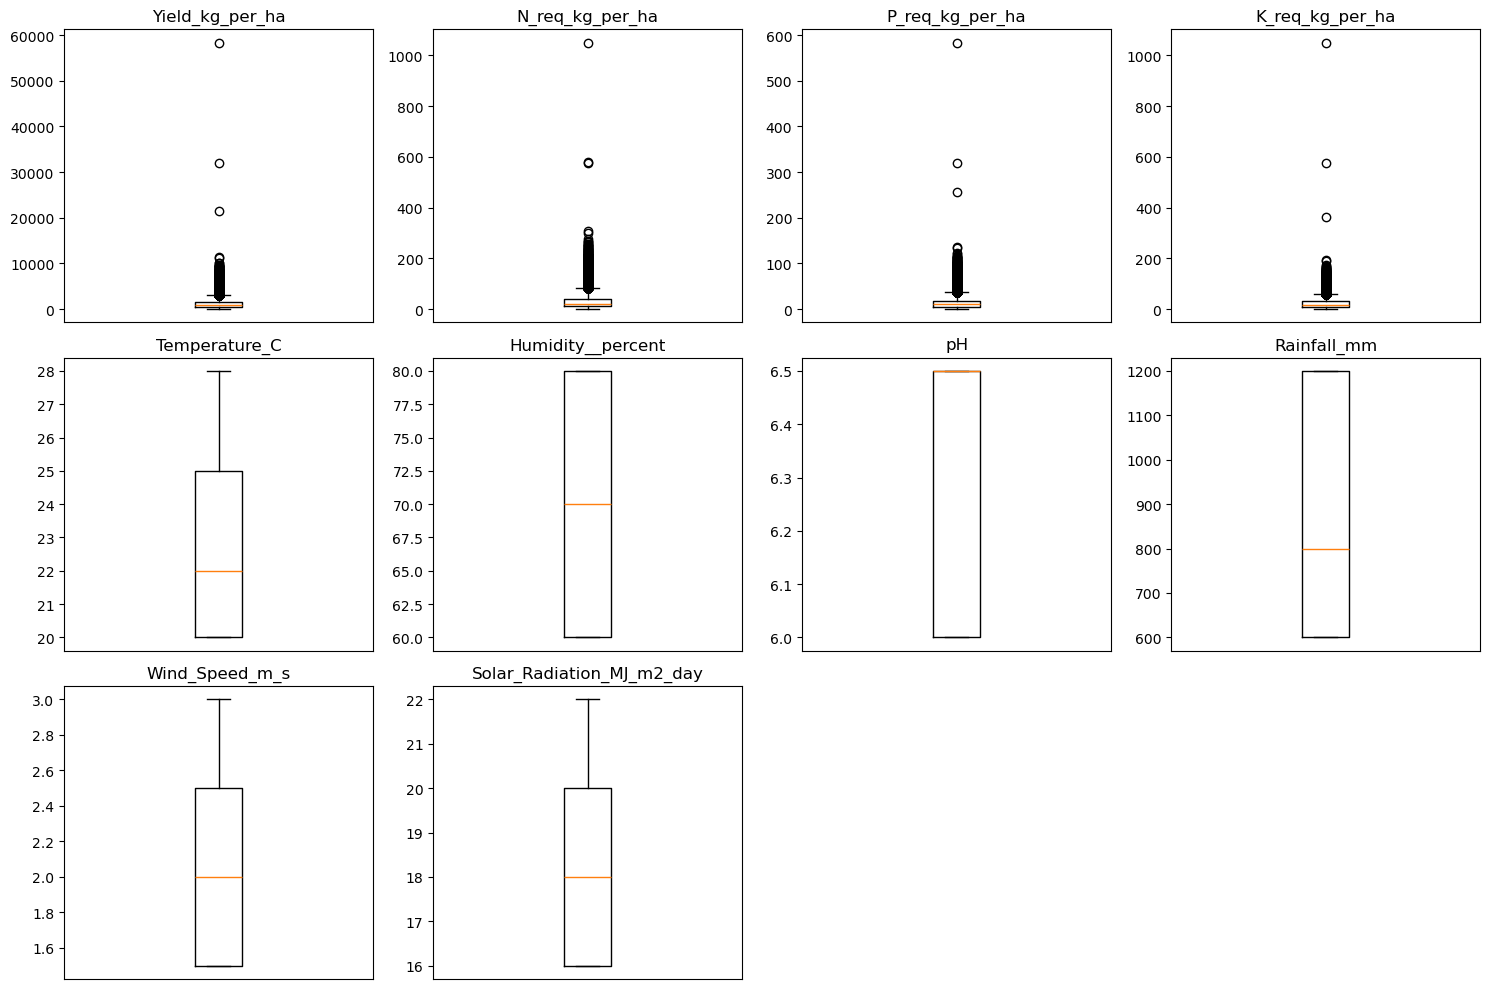

In [70]:
import matplotlib.pyplot as plt

cols = ["Yield_kg_per_ha","N_req_kg_per_ha","P_req_kg_per_ha","K_req_kg_per_ha",
        "Temperature_C","Humidity__percent","pH","Rainfall_mm",
        "Wind_Speed_m_s","Solar_Radiation_MJ_m2_day"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)   # 3 rows, 4 columns
    plt.boxplot(df[col])
    plt.title(col)
    plt.xticks([])

plt.tight_layout()
plt.show()

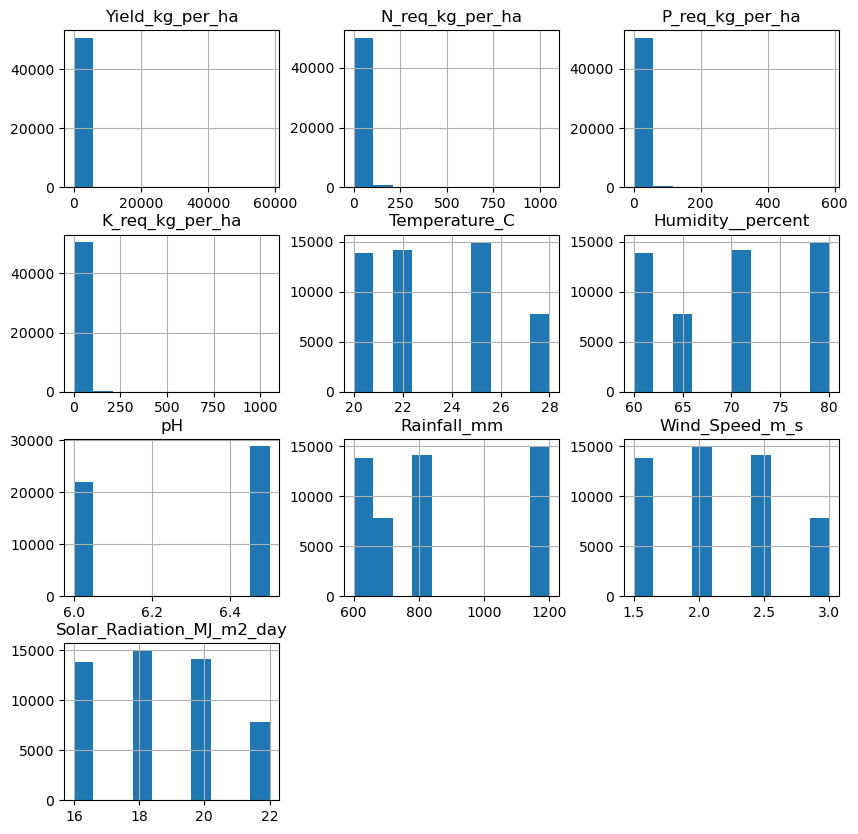

In [71]:
# check the skewness using the histogram:
cols=["Yield_kg_per_ha","N_req_kg_per_ha","P_req_kg_per_ha","K_req_kg_per_ha",
      "Temperature_C","Humidity__percent","pH","Rainfall_mm","Wind_Speed_m_s",
      "Solar_Radiation_MJ_m2_day"]
df[cols].hist(figsize=(10,10))
plt.show()

In [72]:
# checking the outlier's in colums using the IQR method:
columns=["Yield_kg_per_ha","N_req_kg_per_ha","P_req_kg_per_ha",
         "K_req_kg_per_ha","Temperature_C","Humidity__percent",
         "pH","Rainfall_mm","Wind_Speed_m_s",
         "Solar_Radiation_MJ_m2_day"]
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} → {len(outliers)} outliers")

Yield_kg_per_ha → 2253 outliers
N_req_kg_per_ha → 1910 outliers
P_req_kg_per_ha → 2142 outliers
K_req_kg_per_ha → 2629 outliers
Temperature_C → 0 outliers
Humidity__percent → 0 outliers
pH → 0 outliers
Rainfall_mm → 0 outliers
Wind_Speed_m_s → 0 outliers
Solar_Radiation_MJ_m2_day → 0 outliers


In [73]:
# Handling the outliers in columns using the cap-method:
cols = ['N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha','Yield_kg_per_ha']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)
columns=["Yield_kg_per_ha","N_req_kg_per_ha","P_req_kg_per_ha","K_req_kg_per_ha",
         "Temperature_C","Humidity__percent","pH","Rainfall_mm","Wind_Speed_m_s",
         "Solar_Radiation_MJ_m2_day"]
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} → {len(outliers)} outliers")

Yield_kg_per_ha → 0 outliers
N_req_kg_per_ha → 0 outliers
P_req_kg_per_ha → 0 outliers
K_req_kg_per_ha → 0 outliers
Temperature_C → 0 outliers
Humidity__percent → 0 outliers
pH → 0 outliers
Rainfall_mm → 0 outliers
Wind_Speed_m_s → 0 outliers
Solar_Radiation_MJ_m2_day → 0 outliers


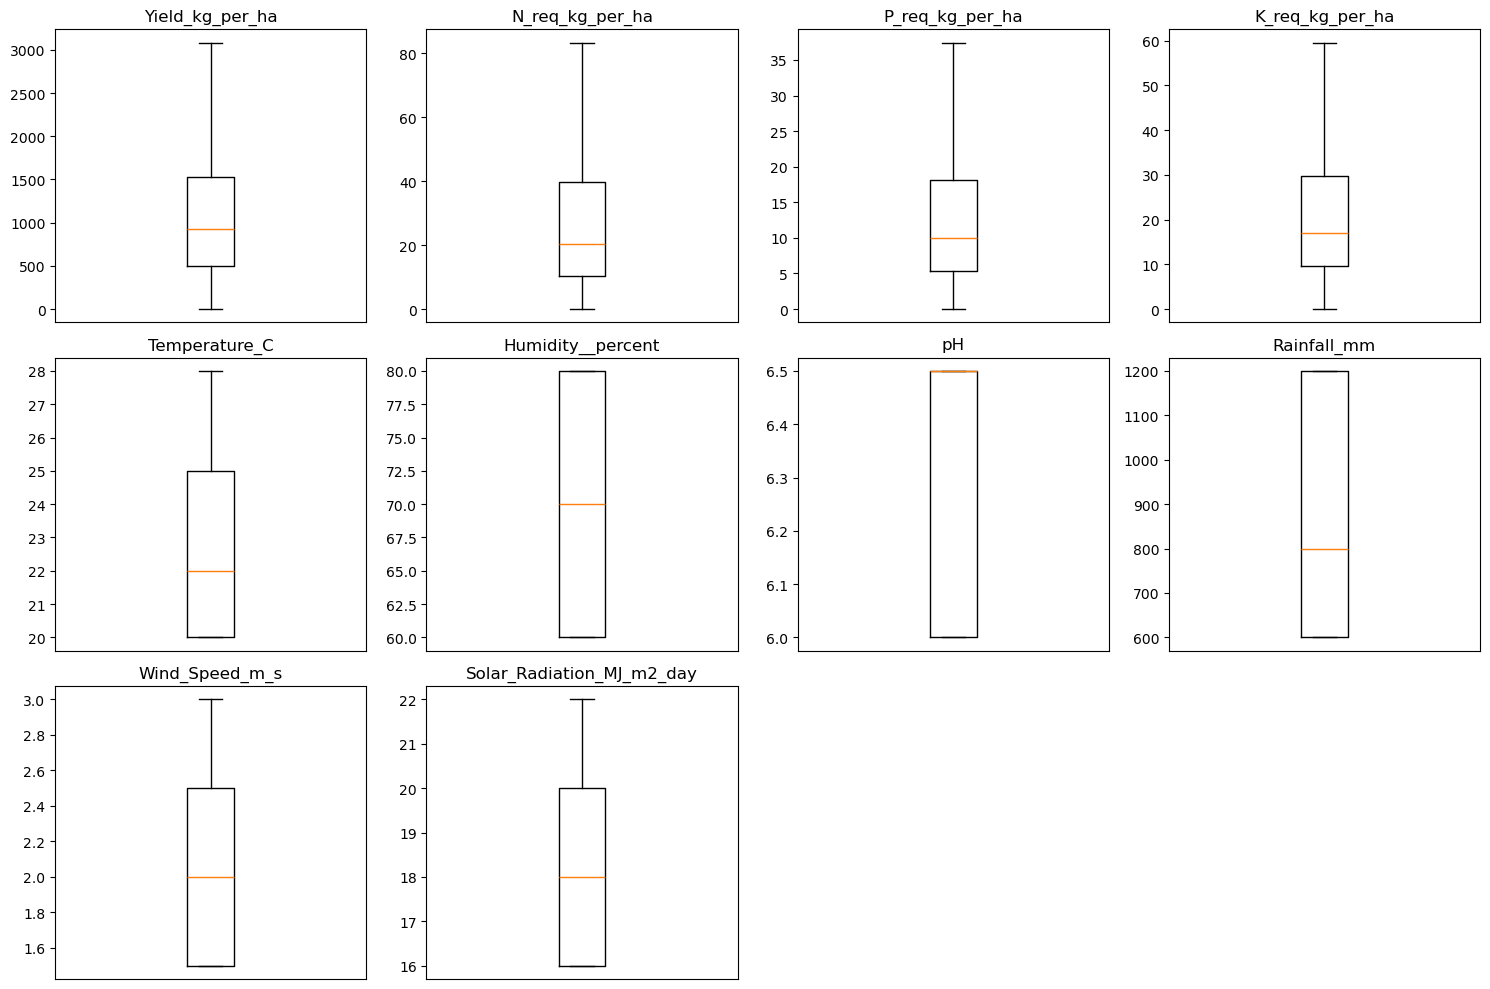

In [74]:
# checking the outliers in columns using the boxplot(after appling the cap-method):
cols = ["Yield_kg_per_ha","N_req_kg_per_ha","P_req_kg_per_ha","K_req_kg_per_ha",
        "Temperature_C","Humidity__percent","pH","Rainfall_mm",
        "Wind_Speed_m_s","Solar_Radiation_MJ_m2_day"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)   # 3 rows, 4 columns
    plt.boxplot(df[col])
    plt.title(col)
    plt.xticks([])

plt.tight_layout()
plt.show()

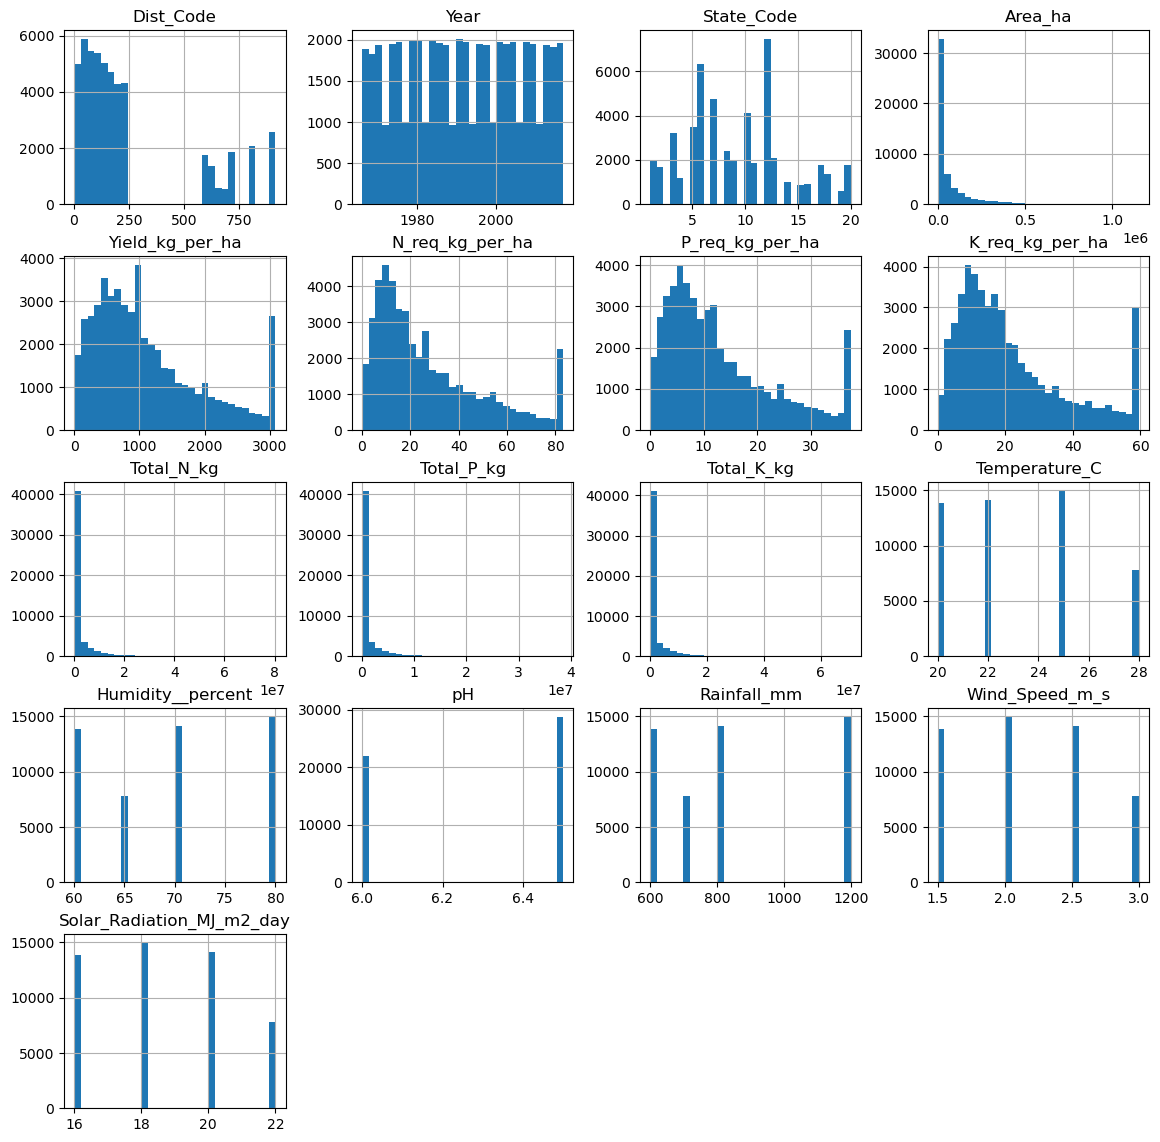

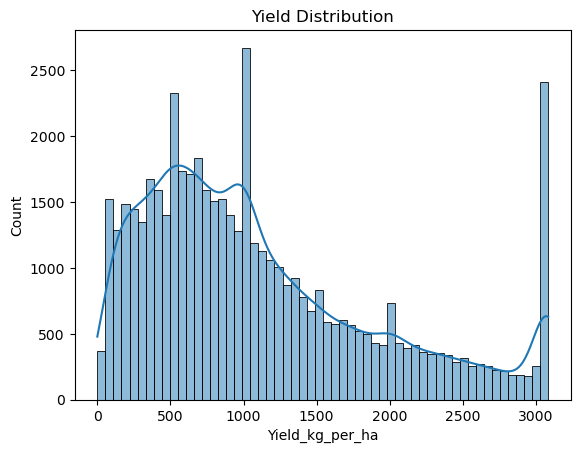

State_Name
Uttar Pradesh       7488
Madhya Pradesh      6339
Maharashtra         4734
Rajasthan           4100
Karnataka           3473
Gujarat             3211
Orissa              2410
West Bengal         2077
Andhra Pradesh      1996
Punjab              1975
Tamil Nadu          1864
Telangana           1774
Assam               1761
Bihar               1693
Himachal Pradesh    1351
Haryana             1201
Chhattisgarh         981
Uttarakhand          894
Jharkhand            864
Kerala               579
Name: count, dtype: int64
Crop
rice        14978
maize       14136
chickpea    13847
cotton       7804
Name: count, dtype: int64


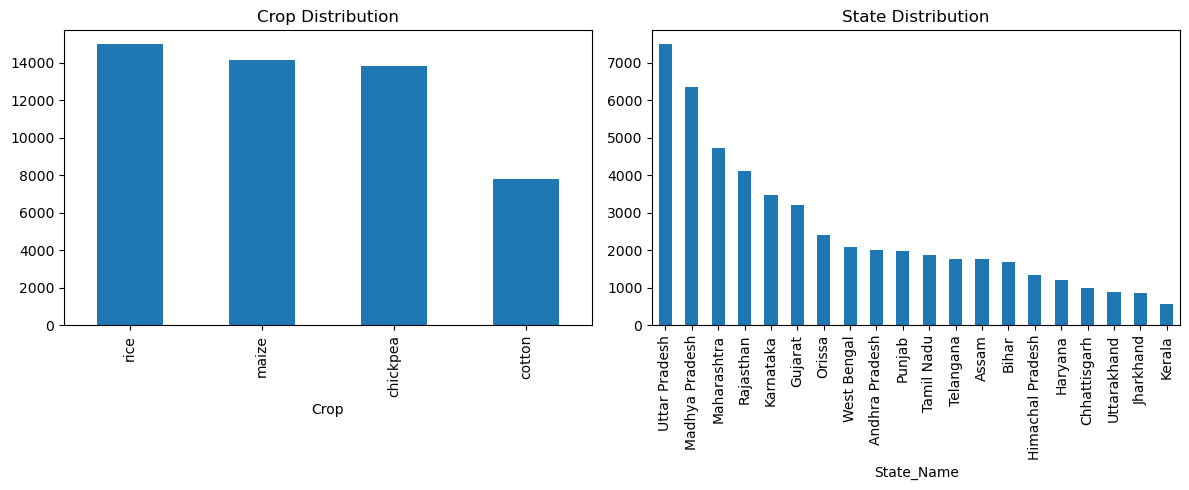

In [75]:
# Univariate Analysis:
# Numerical Features:
# hist plot for the all numerical features:
df.hist(figsize=(14,14), bins=30)
plt.show()
# distribustion plot for the target variable(better than hist plot):
sns.histplot(df["Yield_kg_per_ha"],kde=True)
plt.title("Yield Distribution")
plt.show()
# categorical variables:
# frequency count:
state_value_count=df["State_Name"].value_counts()
crop_value_count=df["Crop"].value_counts()
print(state_value_count)
print(crop_value_count)
# Bar plot for categorical varible:
plt.figure(figsize=(12,5))
# Plot 1: Crop
plt.subplot(1,2,1)
df["Crop"].value_counts().plot(kind="bar")
plt.title("Crop Distribution")
# Plot 2: State
plt.subplot(1,2,2)
df["State_Name"].value_counts().plot(kind="bar")
plt.title("State Distribution")
plt.tight_layout()
plt.show()

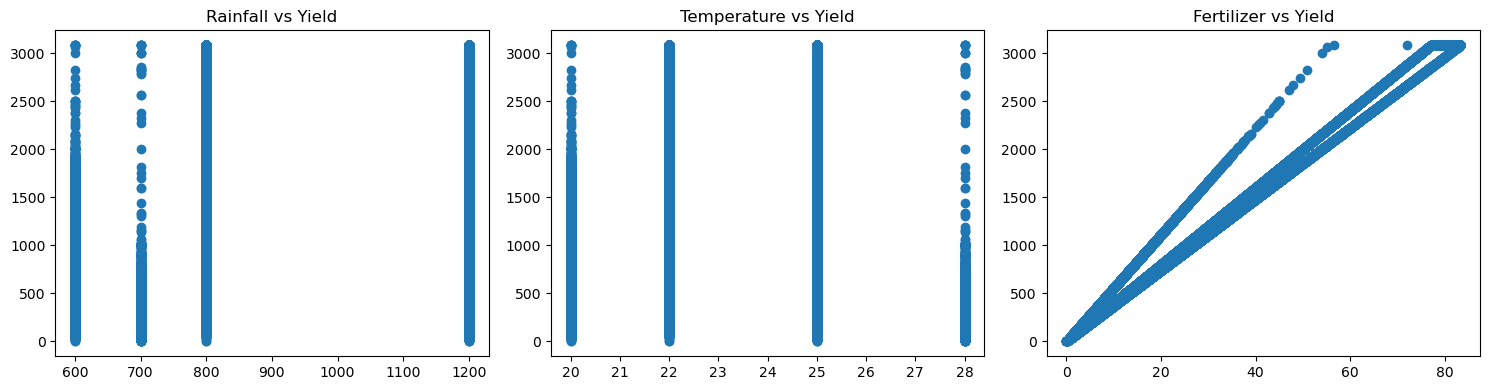

In [76]:
# Bivariate Analysis:
# scatter plot(numeric vs numeric)
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(df['Rainfall_mm'], df['Yield_kg_per_ha'])
plt.title("Rainfall vs Yield")
plt.subplot(1, 3, 2)
plt.scatter(df['Temperature_C'], df['Yield_kg_per_ha'])
plt.title("Temperature vs Yield")
plt.subplot(1, 3, 3)
plt.scatter(df['N_req_kg_per_ha'], df['Yield_kg_per_ha'])
plt.title("Fertilizer vs Yield")
plt.tight_layout()
plt.show()

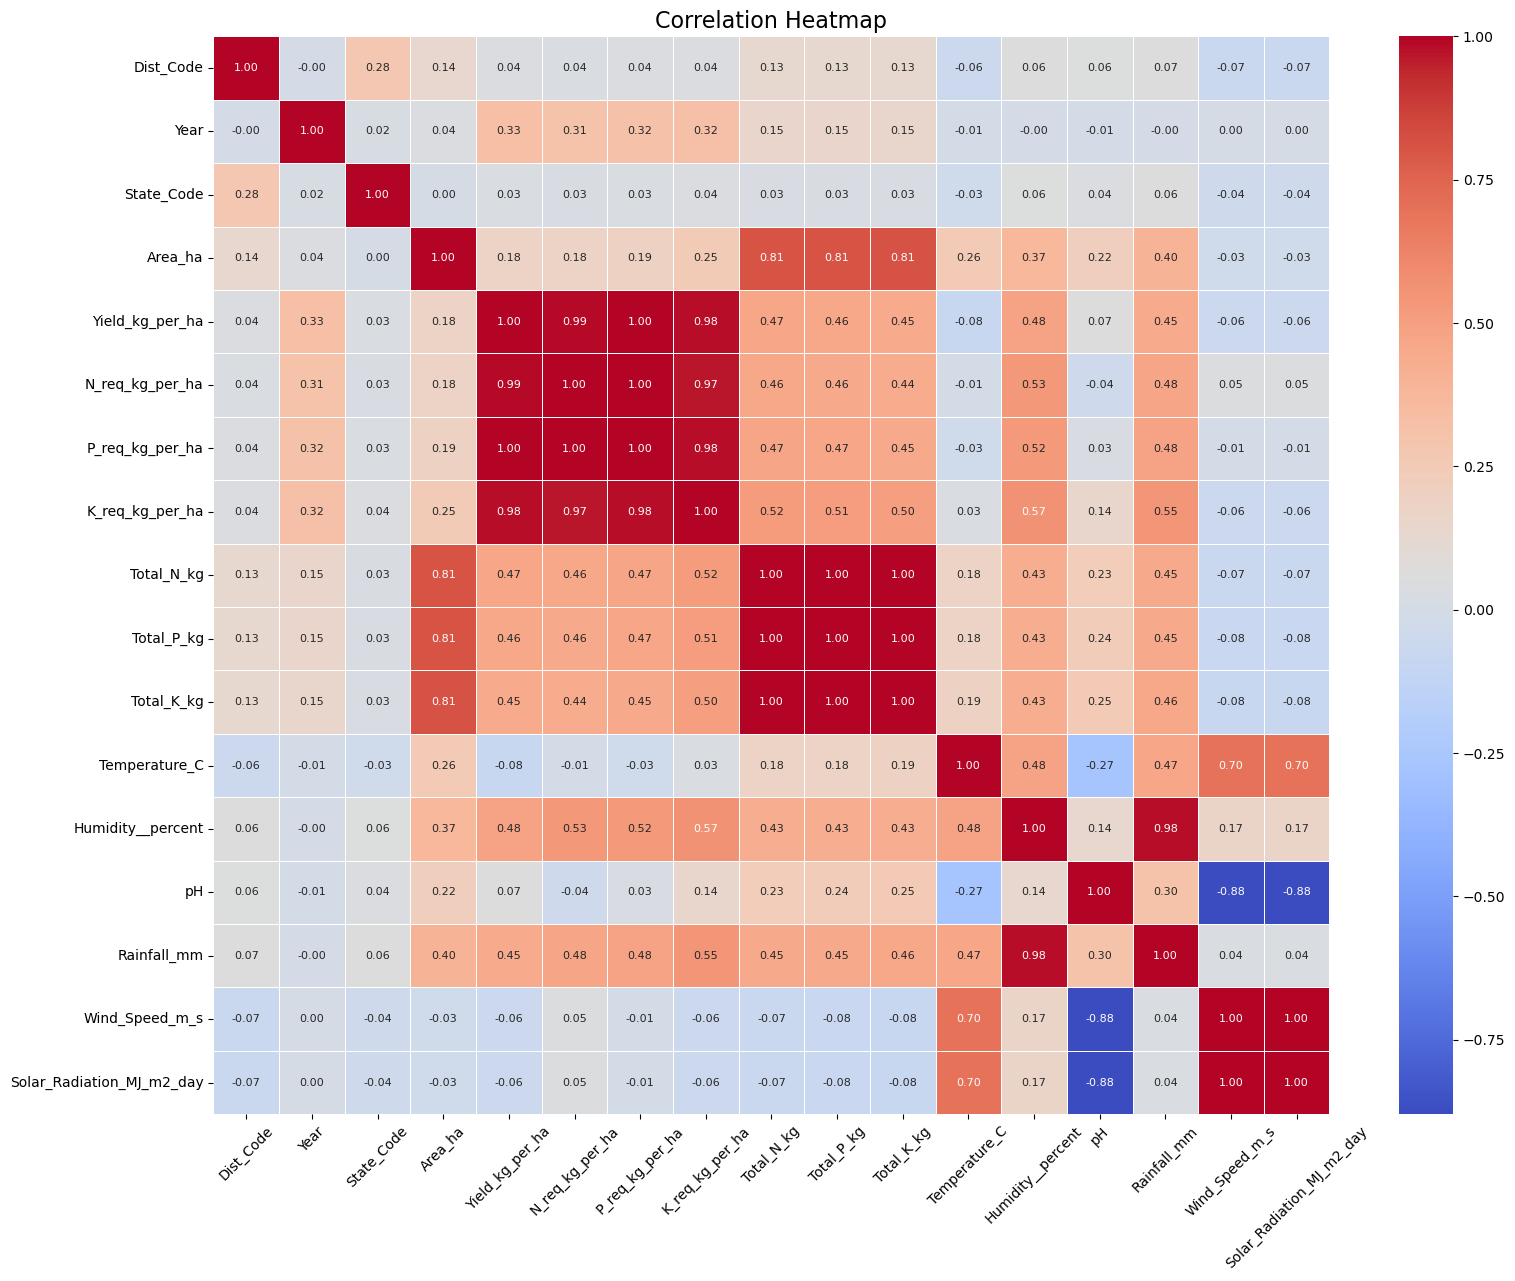

In [77]:
# Correlation analysis
corr = df.corr(numeric_only=True)
plt.figure(figsize=(18, 14))   
sns.heatmap(
    corr,
    annot=True,                
    fmt=".2f",                 
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 8}      
)
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.savefig("corr_plots.png", dpi=300)
plt.show()

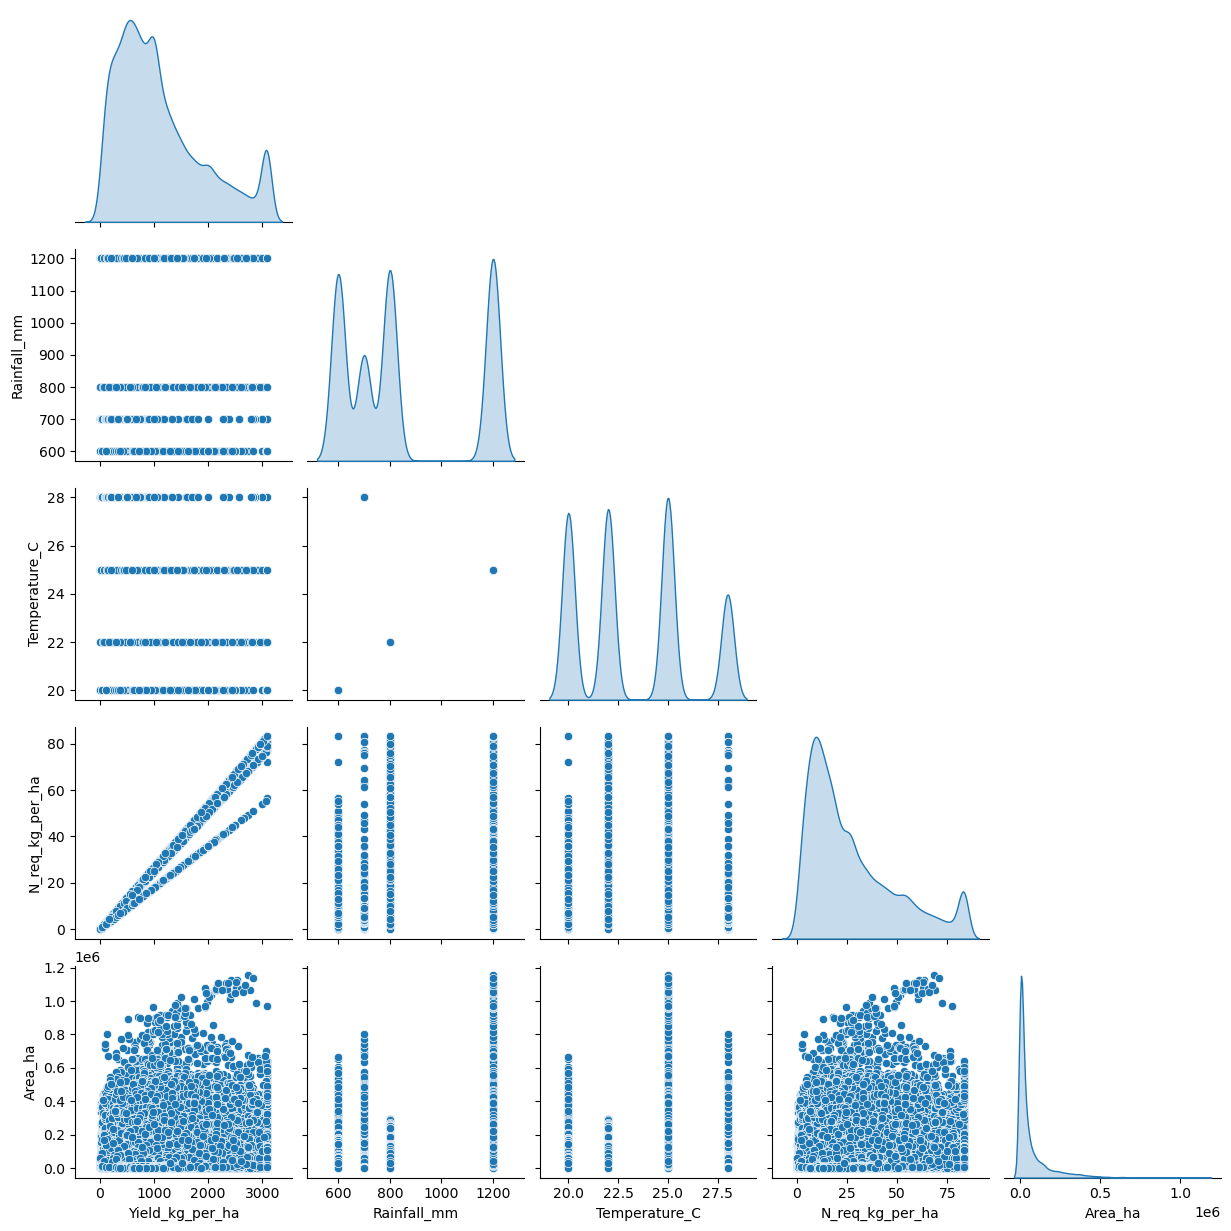

In [78]:
# check feature distribustion:
important_cols = [ "Yield_kg_per_ha","Rainfall_mm","Temperature_C",
                  "N_req_kg_per_ha","Area_ha"]
sns.pairplot(df[important_cols], corner=True, diag_kind='kde')
plt.savefig("pair_plots.png", dpi=300)
plt.show()

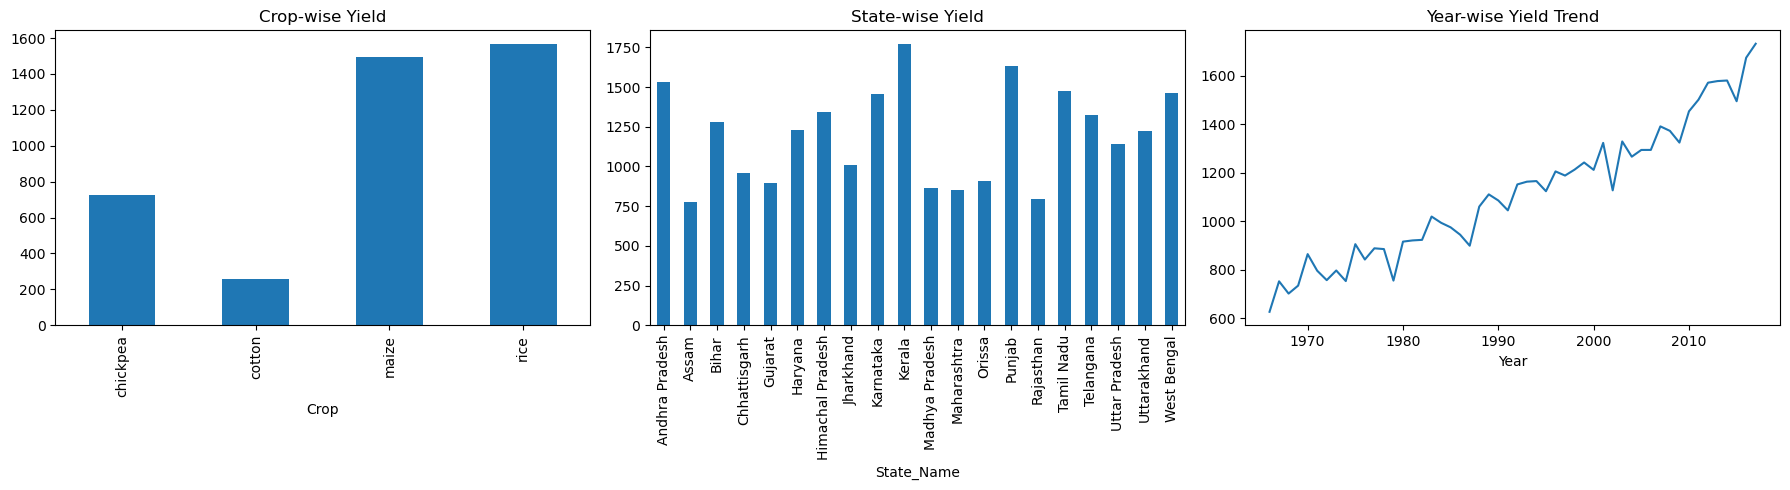

In [79]:
# identify patterns/trend:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df.groupby("Crop")["Yield_kg_per_ha"].mean().plot(
    kind="bar", ax=axes[0], title="Crop-wise Yield"
)
axes[0].tick_params(axis='x', rotation=90)
df.groupby("State_Name")["Yield_kg_per_ha"].mean().plot(
    kind="bar", ax=axes[1], title="State-wise Yield"
)
axes[1].tick_params(axis='x', rotation=90)
df.groupby("Year")["Yield_kg_per_ha"].mean().plot(
    ax=axes[2], title="Year-wise Yield Trend"
)
plt.tight_layout()
plt.show()

In [80]:
# creating the new features:
df['Total_Fertilizer'] =(df['N_req_kg_per_ha'] + df['P_req_kg_per_ha'] + df['K_req_kg_per_ha']).round(2)

In [81]:
# checking the skewness of the columns
df.skew(numeric_only=True)

Dist_Code                    1.364890
Year                         0.000548
State_Code                   0.397943
Area_ha                      3.199830
Yield_kg_per_ha              0.937961
N_req_kg_per_ha              1.045239
P_req_kg_per_ha              0.994732
K_req_kg_per_ha              1.005970
Total_N_kg                   4.713511
Total_P_kg                   4.742728
Total_K_kg                   4.817770
Temperature_C                0.369338
Humidity__percent            0.217724
pH                          -0.273788
Rainfall_mm                  0.594472
Wind_Speed_m_s               0.182468
Solar_Radiation_MJ_m2_day    0.182468
Total_Fertilizer             1.007959
dtype: float64

In [82]:
# handling the skewed data
# Log transforms
df['Area_ha'] = np.log1p(df['Area_ha'])
df['Rainfall_mm'] = np.log1p(df['Rainfall_mm'])
df['P_req_kg_per_ha'] = np.log1p(df['P_req_kg_per_ha'])
# Box-Cox transforms
df['N_req_kg_per_ha'], _ = boxcox(df['N_req_kg_per_ha'] + 1)
df['K_req_kg_per_ha'], _ = boxcox(df['K_req_kg_per_ha'] + 1)
df['Total_Fertilizer'], _ = boxcox(df['Total_Fertilizer'] + 1)

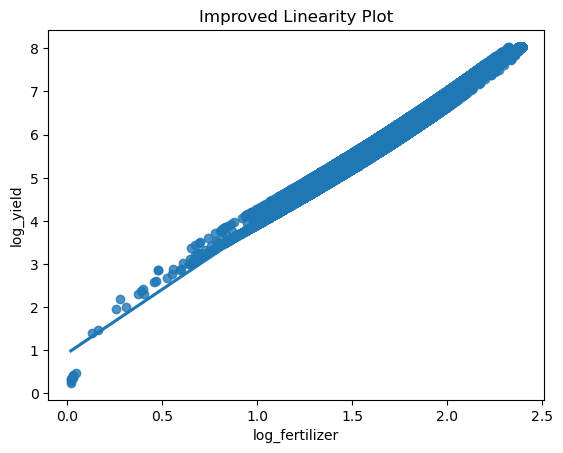

In [177]:
# checking the skewness of the columns
df.skew(numeric_only=True)
df['log_fertilizer'] = np.log1p(df['Total_Fertilizer'])

sns.regplot(x=df['log_fertilizer'], y=df['log_yield'])
plt.title("Improved Linearity Plot")
plt.show()

In [84]:
# Detecting and Droping the highly correlated features:
num_df = df.select_dtypes(include=np.number)

corr_matrix = num_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    col for col in upper.columns if any(upper[col] > 0.9)
]

print("Highly Correlated Features:", high_corr_features)
important_features = ['Total_Fertilizer','Rainfall_mm',
    'Temperature_C','pH']
features_to_drop = [
    col for col in high_corr_features if col not in important_features
]
df = df.drop(columns=features_to_drop, errors='ignore')
print("\nDropped Features:", features_to_drop)
print("\nRemaining Columns:")
print(df.columns)

Highly Correlated Features: ['N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_P_kg', 'Total_K_kg', 'Rainfall_mm', 'Solar_Radiation_MJ_m2_day', 'Total_Fertilizer']

Dropped Features: ['N_req_kg_per_ha', 'P_req_kg_per_ha', 'K_req_kg_per_ha', 'Total_P_kg', 'Total_K_kg', 'Solar_Radiation_MJ_m2_day']

Remaining Columns:
Index(['Dist_Code', 'Year', 'State_Code', 'State_Name', 'Dist_Name', 'Crop',
       'Area_ha', 'Yield_kg_per_ha', 'Total_N_kg', 'Temperature_C',
       'Humidity__percent', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s',
       'Total_Fertilizer'],
      dtype='object')


In [85]:
# clean the colmn names  Encoding(one-hot encoding) the categorical columns:
# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("%", "")
df.columns = df.columns.str.replace("/", "")
# Encoding(one-hot encoding) the categorical columns:
# Identify columns safely
cols_to_encode = []
if 'State_Name' in df.columns:
    cols_to_encode.append('State_Name')
if 'Crop' in df.columns:
    cols_to_encode.append('Crop')
# Apply one-hot encoding with integer output
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
# Convert ONLY dummy columns (bool → int)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
# Final check
print(df.head())
print(df.dtypes)

   Dist_Code  Year  State_Code Dist_Name    Area_ha  Yield_kg_per_ha  \
0          1  1966          14      Durg  13.214032           337.59   
1          1  1966          14      Durg   8.006701           666.67   
2          1  1966          14      Durg  10.896758           500.00   
3          1  1967          14      Durg  13.212206           747.71   
4          1  1967          14      Durg   8.006701          1000.00   

    Total_N_kg  Temperature_C  Humidity__percent   pH  ...  State_Name_Punjab  \
0   4624983.00             25                 80  6.5  ...                  0   
1     54000.27             22                 70  6.0  ...                  0   
2    486000.00             20                 60  6.5  ...                  0   
3  10224934.25             25                 80  6.5  ...                  0   
4     81000.00             22                 70  6.0  ...                  0   

   State_Name_Rajasthan  State_Name_Tamil Nadu  State_Name_Telangana  \
0       

In [155]:
# Scalling the numerical columns:
# Define X and y
X = df.drop('Yield_kg_per_ha', axis=1)
y = df['Yield_kg_per_ha']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Automatically select numeric columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns used for scaling:")
print(num_cols)
# Scaling
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Numeric columns used for scaling:
Index(['Dist_Code', 'Year', 'State_Code', 'Area_ha', 'Total_N_kg',
       'Temperature_C', 'Humidity__percent', 'pH', 'Rainfall_mm',
       'Wind_Speed_m_s', 'Total_Fertilizer', 'log_yield'],
      dtype='object')


In [87]:
# checking the Variance Inflation Factor:
X = df.select_dtypes(include=['float64','int64'])
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


              Feature        VIF
0           Dist_Code   1.135702
1                Year   1.247822
2          State_Code   1.097371
3             Area_ha   1.464501
4     Yield_kg_per_ha  12.986665
5          Total_N_kg   1.861418
6       Temperature_C        inf
7   Humidity__percent        inf
8                  pH        inf
9         Rainfall_mm        inf
10     Wind_Speed_m_s        inf
11   Total_Fertilizer  16.484439


In [88]:
# Automatically select relevant numeric columns
print(df.columns.tolist())
cols = [col for col in df.columns if any(x in col for x in 
        ['Temperature', 'Humidity', 'Rainfall', 'Wind', 'Solar'])]

print("Using columns:", cols)


['Dist_Code', 'Year', 'State_Code', 'Dist_Name', 'Area_ha', 'Yield_kg_per_ha', 'Total_N_kg', 'Temperature_C', 'Humidity__percent', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s', 'Total_Fertilizer', 'State_Name_Assam', 'State_Name_Bihar', 'State_Name_Chhattisgarh', 'State_Name_Gujarat', 'State_Name_Haryana', 'State_Name_Himachal Pradesh', 'State_Name_Jharkhand', 'State_Name_Karnataka', 'State_Name_Kerala', 'State_Name_Madhya Pradesh', 'State_Name_Maharashtra', 'State_Name_Orissa', 'State_Name_Punjab', 'State_Name_Rajasthan', 'State_Name_Tamil Nadu', 'State_Name_Telangana', 'State_Name_Uttar Pradesh', 'State_Name_Uttarakhand', 'State_Name_West Bengal', 'Crop_cotton', 'Crop_maize', 'Crop_rice']
Using columns: ['Temperature_C', 'Humidity__percent', 'Rainfall_mm', 'Wind_Speed_m_s']


In [89]:
# Define Features & Target
X = df.drop(['Yield_kg_per_ha'], axis=1)
y = df['Yield_kg_per_ha']
# Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Feature Scaling (ONLY for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Adjusted R2 Function
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)
# Define Models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=10),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    )
}
# Train & Evaluate
results = []

for name, model in models.items():
    
    if name in ["Linear Regression", "Lasso", "Ridge"]:
        # Use scaled data
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    
    else:
        # Tree model (no scaling needed)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

    # Metrics
    r2 = r2_score(y_test, y_pred)
    adj_r2 = adjusted_r2(r2, X_test.shape[0], X_test.shape[1])
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, adj_r2, mse, rmse, mae, cv_score])
# Results Table
results_df = pd.DataFrame(results, columns=[
    "Model", "R2", "Adjusted R2", "MSE", "RMSE", "MAE", "CV Score"
])

print("\n📊 Model Comparison:\n")
print(results_df)


📊 Model Comparison:

               Model        R2  Adjusted R2           MSE        RMSE  \
0  Linear Regression  0.931129     0.928721  46112.401549  214.737983   
1              Lasso  0.932076     0.929701  45477.965381  213.255634   
2              Ridge  0.932010     0.929632  45522.530462  213.360096   
3      Random Forest  0.856452     0.851432  96112.116370  310.019542   

          MAE  CV Score  
0  160.361214  0.930830  
1  158.883674  0.931306  
2  159.017802  0.931279  
3  221.935063  0.861372  


In [90]:
# checking the overfitting in the fitted model:
train_score = models["Lasso"].score(X_train_scaled, y_train)
test_score = models["Lasso"].score(X_test_scaled, y_test)
print("Train R2:", train_score)
print("Test R2 :", test_score)

Train R2: 0.9325062107381421
Test R2 : 0.9320764359804988


In [91]:
# Creating a single input sample (row) that matches your trained ML model format:
feature_columns = X.columns
def create_input(year, area, fertilizer, state, crop):
    
    # Create empty dataframe with SAME columns
    input_df = pd.DataFrame(columns=feature_columns)
    input_df.loc[0] = 0

    # Fill only existing columns
    if 'Year' in input_df.columns:
        input_df['Year'] = year

    if 'Area_ha' in input_df.columns:
        input_df['Area_ha'] = area

    if 'Total_Fertilizer' in input_df.columns:
        input_df['Total_Fertilizer'] = fertilizer

    # State encoding (exact match)
    state_col = f"State_Name_{state}"
    if state_col in input_df.columns:
        input_df[state_col] = 1

    # Crop encoding
    crop_col = f"Crop_{crop}"
    if crop_col in input_df.columns:
        input_df[crop_col] = 1

    return input_df

In [92]:
# =========================
# 1. Linear Regression (Get Coefficients)
# =========================
from sklearn.linear_model import LinearRegression

X_simple = df[['Total_Fertilizer', 'Rainfall_mm']]
y_simple = df['Yield_kg_per_ha']

lr = LinearRegression()
lr.fit(X_simple, y_simple)

# Extract coefficients
a = lr.coef_[0]
b = lr.coef_[1]
c = lr.intercept_

# =========================
# 2. Scale Coefficients (VERY IMPORTANT)
# =========================
# Ensure realistic agricultural values

a = min(max(a, 1), 10)     # fertilizer effect (1 to 10)
b = min(max(b, 0.5), 5)    # water effect (0.5 to 5)
c = max(c, 500)            # base yield

print("Adjusted Coefficients:")
print("a (Fertilizer):", a)
print("b (Water):", b)
print("c (Base Yield):", c)


# =========================
# 3. Define Optimization Model
# =========================
from pulp import *

model = LpProblem("Farm_Optimization", LpMaximize)

# Decision Variables
F = LpVariable('Fertilizer', lowBound=0)
W = LpVariable('Water', lowBound=0)


# =========================
# 4. Parameters (REALISTIC)
# =========================
price = 20      # ₹ per kg yield
cost_F = 2      # ₹ per kg fertilizer
cost_W = 1      # ₹ per mm water

budget = 10000

F_max = 150
W_max = 1000

area = 1   # per hectare (IMPORTANT)


# =========================
# 5. Objective Function
# =========================
model += price * (a*F + b*W + c) * area - cost_F*F - cost_W*W


# =========================
# 6. Constraints
# =========================
model += F <= F_max
model += W <= W_max

model += F >= 50
model += W >= 300

model += cost_F*F + cost_W*W <= budget


# =========================
# 7. Solve Model
# =========================
model.solve()


# =========================
# 8. Results
# =========================
from pulp import LpStatus, value

print("\nStatus:", LpStatus[model.status])

print("\n🔹 Optimal Solution:")
print("Fertilizer (kg):", F.varValue)
print("Water (mm):", W.varValue)

print("\n💰 Maximum Profit:", value(model.objective))

Adjusted Coefficients:
a (Fertilizer): 10
b (Water): 0.5
c (Base Yield): 500

Status: Optimal

🔹 Optimal Solution:
Fertilizer (kg): 150.0
Water (mm): 1000.0

💰 Maximum Profit: 48700.0
